In [183]:
from skimage.io import imread
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
import seaborn as sns

In [184]:
# Load summary
project = "BBBC014"
predictions_file = "Channel_2-44-D-08-00_e10_rf0.7_predictions.csv"
isonuc_folder    = "Channel_2-44-D-08-00_e10_rf0.7"

project_dir = Path(f"/Users/miguelibarra/PycharmProjects/cin/data/Broad/{project}").resolve()

# Read in predictions
predictions = pd.read_csv(project_dir/ f"predictions/{predictions_file}")

In [177]:
# Select images to show
images = predictions[predictions["micronuclei"]>0]
images


,image,score,micronuclei
53,Channel_2-44-D-08-00_729.png,1.102061,1
107,Channel_2-44-D-08-00_211.png,0.605333,1
135,Channel_2-44-D-08-00_618.png,1.047712,1
167,Channel_2-44-D-08-00_585.png,0.920709,1
347,Channel_2-44-D-08-00_487.png,0.598661,1
516,Channel_2-44-D-08-00_421.png,0.882475,1
650,Channel_2-44-D-08-00_21.png,0.699352,1
651,Channel_2-44-D-08-00_31.png,0.905282,1
677,Channel_2-44-D-08-00_876.png,0.585966,1
692,Channel_2-44-D-08-00_477.png,0.788329,1


Channel_2-44-D-08-00_876.png
Channel_2-44-D-08-00_487.png
Channel_2-44-D-08-00_251.png
Channel_2-44-D-08-00_31.png
Channel_2-44-D-08-00_585.png
Channel_2-44-D-08-00_729.png
Channel_2-44-D-08-00_192.png
Channel_2-44-D-08-00_222.png
Channel_2-44-D-08-00_618.png
Channel_2-44-D-08-00_21.png


/var/folders/9c/s912yv1x3dn6xwpfnggf8wt80000gn/T/ipykernel_55878/1834521049.py:14: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


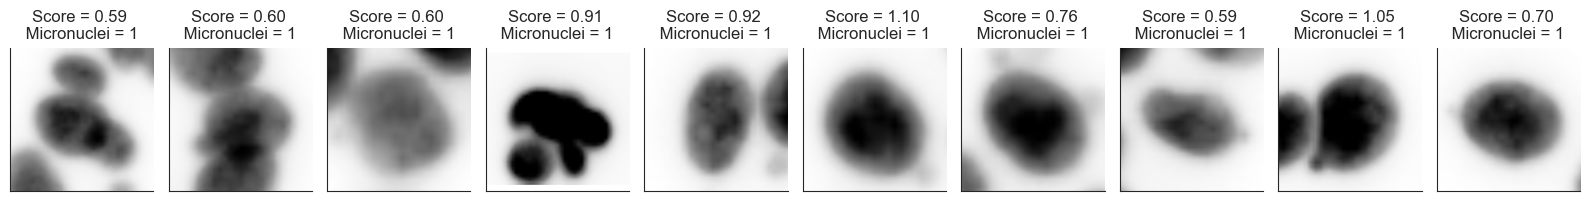

In [182]:
# Iterate over the different images
# Show images without gridlines
sns.set_style("white")
fig, ax = plt.subplots(1, 10 , figsize=(16, 3))
for i,(ix, j) in enumerate(images.sample(10).iterrows()):
    print(j.image)
    # Read images
    im = imread(project_dir/ f"isonuc/{isonuc_folder}/{j.image}")
    ax[i].imshow(im, cmap="Greys")
    ax[i].set_title(f"Score = {j['score']:.2f} \n Micronuclei = {j['micronuclei']} ")
    ax[i].set_yticks([])
    ax[i].set_xticks([])
sns.despine()
fig.show()
fig.tight_layout()
# fig.savefig("../data/test_data/figures_fp.png", dpi=300)